# Playground Series S6E7 — Health Risk Prediction: EDA

3-class classification (`health_condition`: `fit` / `at-risk` / `unhealthy`), scored on **Balanced Accuracy**.

Goals of this notebook:
- Understand target imbalance (balanced accuracy makes minority classes disproportionately important)
- Characterize missingness (11 of 13 features have missing values, 1-12%)
- Look at numeric/categorical distributions conditioned on target
- Check train/test covariate shift
- Surface concrete feature-engineering ideas for the modeling pipeline (`src/features.py`)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100

DATA_DIR = '../data'
train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')
sample_sub = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')

TARGET = 'health_condition'
ID_COL = 'id'

print('train:', train.shape)
print('test :', test.shape)
print('sub  :', sample_sub.shape)


train: (690088, 15)
test : (295753, 14)
sub  : (295753, 2)


## 1. Schema & first look

In [2]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  gender         

In [3]:
train.head(10)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
5,5,at-risk,5.11,82.8,24.43,2290.0,2134.0,29.2,2.02,veg,low,poor,sedentary,occasional,male
6,6,at-risk,8.21,71.1,24.14,2723.0,12984.0,54.5,2.01,balanced,low,NaN,moderate,no,female
7,7,at-risk,7.47,87.0,23.51,NaN,3096.0,37.5,0.51,balanced,low,average,sedentary,occasional,male
8,8,unhealthy,5.94,75.4,24.36,NaN,12165.0,61.6,1.56,veg,high,average,active,no,other
9,9,at-risk,6.97,80.1,20.47,2928.0,13108.0,51.9,2.53,veg,medium,good,active,no,male


In [4]:
num_cols = train.select_dtypes(include=[np.number]).columns.drop(ID_COL).tolist()
cat_cols = [c for c in train.columns if c not in num_cols + [ID_COL, TARGET]]
print('numeric  :', num_cols)
print('categorical:', cat_cols)


numeric  : ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']
categorical: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


## 2. Target distribution

Balanced accuracy weights every class equally regardless of support, so the two minority classes (`unhealthy`, `fit`) matter as much as the dominant `at-risk` class despite being ~6-9% of rows each.

,count,pct
health_condition,,
at-risk,592561,85.87
unhealthy,57724,8.36
fit,39803,5.77


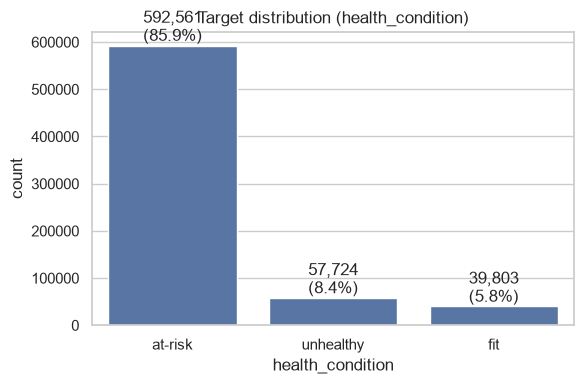

In [5]:
target_counts = train[TARGET].value_counts()
target_pct = train[TARGET].value_counts(normalize=True) * 100
display(pd.DataFrame({'count': target_counts, 'pct': target_pct.round(2)}))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax)
ax.set_title('Target distribution (health_condition)')
ax.set_ylabel('count')
for i, v in enumerate(target_counts.values):
    ax.text(i, v, f'{v:,}\n({target_pct.values[i]:.1f}%)', ha='center', va='bottom')
plt.tight_layout()
plt.show()


**Takeaway:** severe imbalance (`at-risk` ≈ 86%, `unhealthy` ≈ 8%, `fit` ≈ 6%). Implications for the pipeline:
- Use **StratifiedKFold** for CV so fold-level class ratios match the population.
- Prefer models/losses that output calibrated multiclass probabilities (logloss/multi:softprob) — balanced accuracy is then optimized downstream via argmax on OOF-calibrated probabilities, not by training with balanced-accuracy directly.
- Consider `class_weight='balanced'` variants as *additional* diversity in the model zoo, not as the only strategy — the competition writeup explicitly notes over-indexing on public LB (which is influenced by the same imbalance) misled many via blind blending.


## 3. Missing data

,pct_missing
stress_level,12.00
sleep_duration,11.01
sleep_quality,8.45
calorie_expenditure,7.66
water_intake,6.30
physical_activity_level,5.31
smoking_alcohol,4.14
gender,3.10
step_count,2.02
bmi,2.01


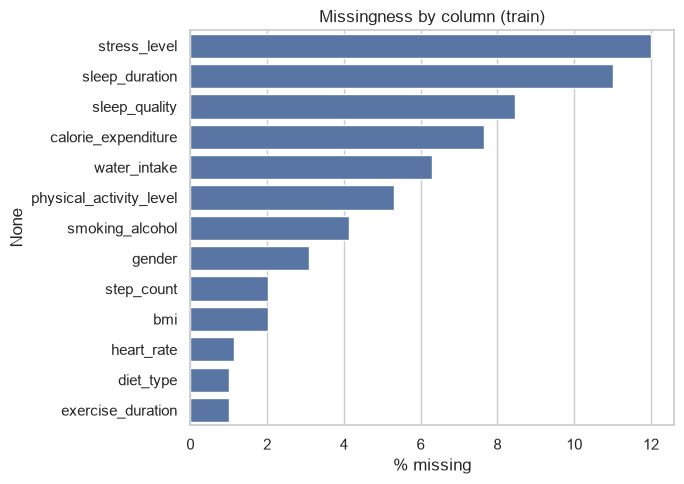

In [6]:
miss = train.isnull().mean().sort_values(ascending=False) * 100
miss = miss[miss > 0]
display(miss.round(2).to_frame('pct_missing'))

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=miss.values, y=miss.index, ax=ax, orient='h')
ax.set_xlabel('% missing')
ax.set_title('Missingness by column (train)')
plt.tight_layout()
plt.show()


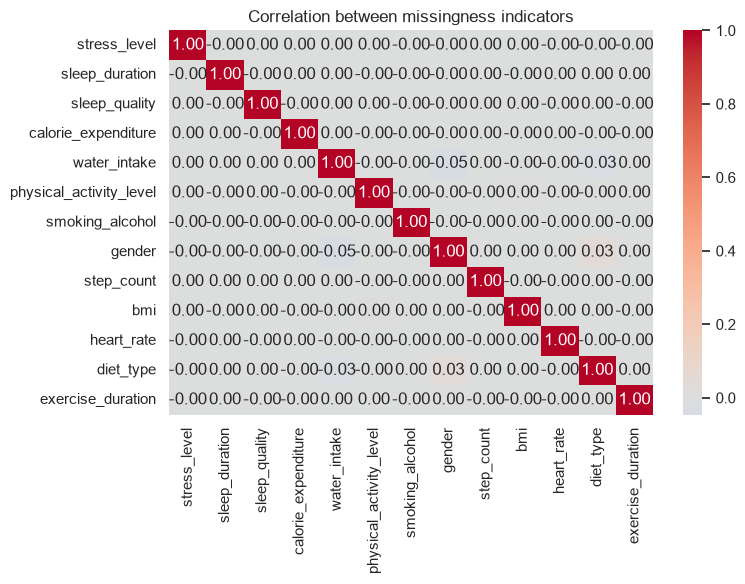

In [7]:
# Missingness co-occurrence: do the same rows tend to be missing across columns?
miss_matrix = train[miss.index].isnull().astype(int)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(miss_matrix.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation between missingness indicators')
plt.tight_layout()
plt.show()


In [8]:
# Does missingness rate differ by target class? (informative missingness -> keep as engineered feature)
rows = []
for c in miss.index:
    grp = train.groupby(TARGET)[c].apply(lambda s: s.isnull().mean() * 100)
    rows.append(grp.rename(c))
miss_by_target = pd.concat(rows, axis=1).T
display(miss_by_target.round(2))


health_condition,at-risk,fit,unhealthy
stress_level,12.00,11.96,11.99
sleep_duration,11.02,10.94,10.97
sleep_quality,8.46,8.53,8.31
calorie_expenditure,7.65,7.70,7.69
water_intake,6.27,6.34,6.54
physical_activity_level,5.31,5.26,5.29
smoking_alcohol,4.13,4.14,4.24
gender,3.10,2.99,3.19
step_count,2.02,1.99,1.95
bmi,2.08,2.86,0.71


**Takeaway:** if missingness rates vary meaningfully by class, `missing indicator` columns (one per feature) are worth including in the heavy-FE feature set — cheap and often informative on synthetic/generated playground data.

## 4. Numeric feature distributions

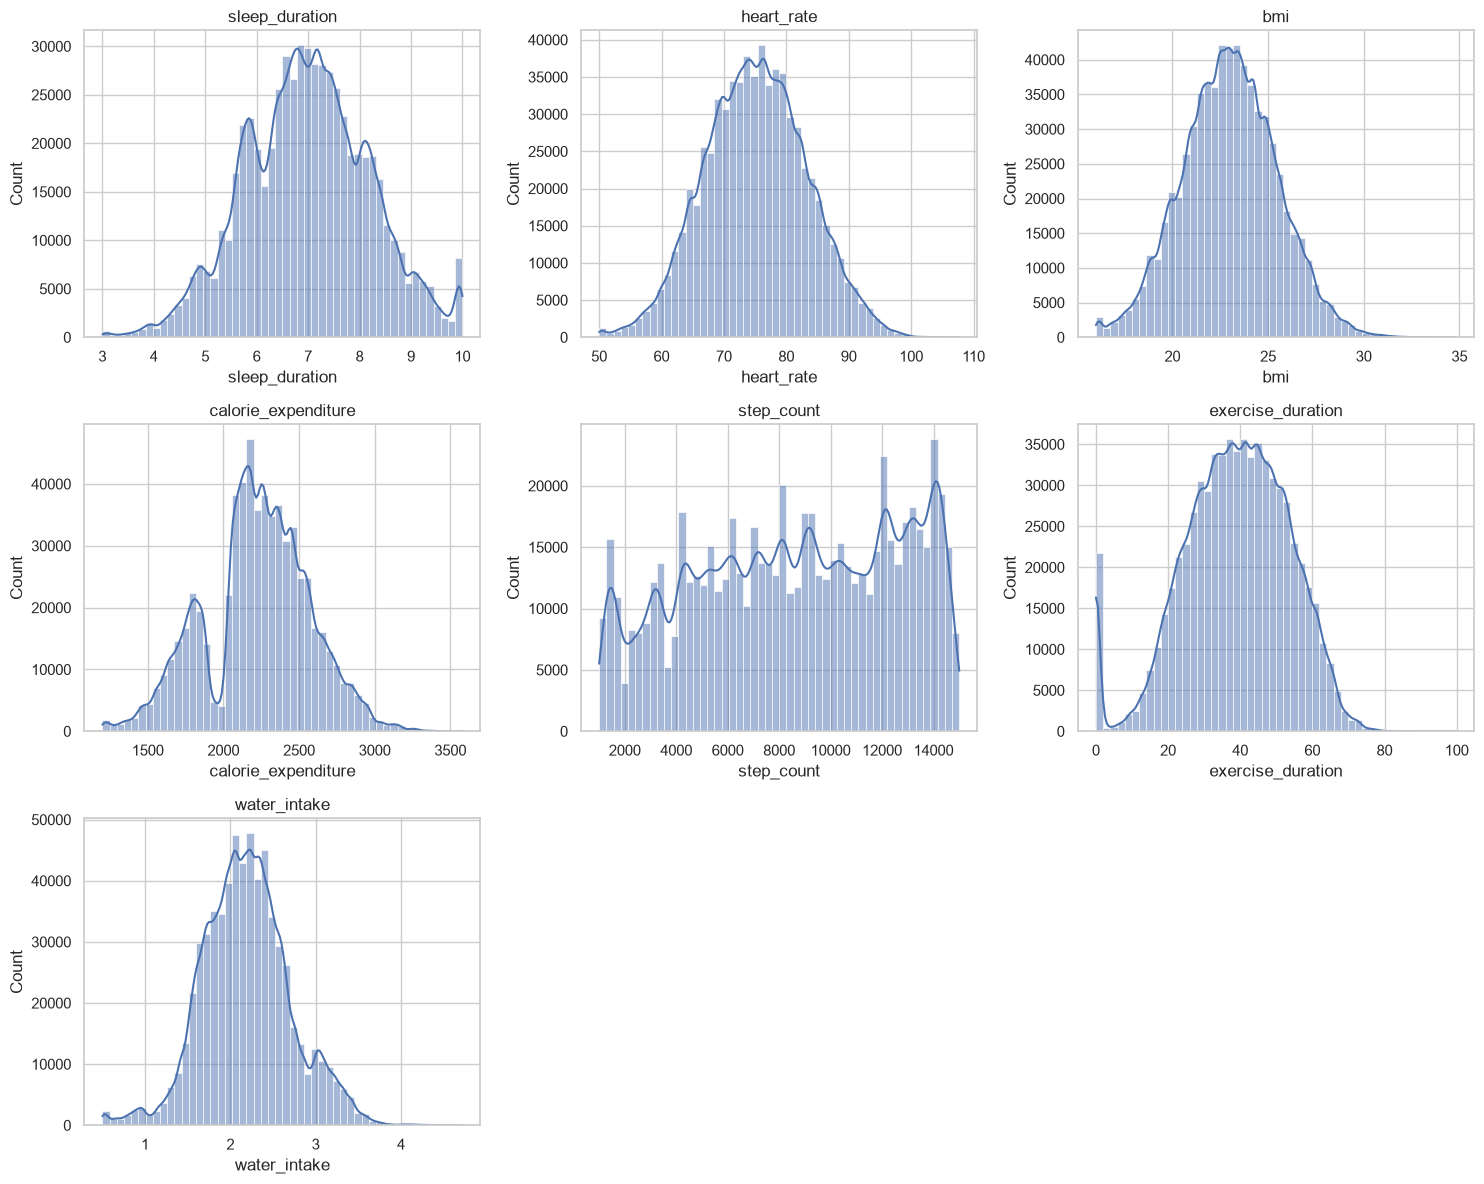

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, c in zip(axes.flat, num_cols):
    sns.histplot(train[c].dropna(), kde=True, ax=ax, bins=50)
    ax.set_title(c)
for ax in axes.flat[len(num_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


In [10]:
display(train[num_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


In [11]:
# Skewness / kurtosis - flags candidates for log/sqrt transforms
skew_kurt = pd.DataFrame({
    'skew': train[num_cols].skew(),
    'kurtosis': train[num_cols].kurtosis(),
})
display(skew_kurt.round(3))


,skew,kurtosis
sleep_duration,-0.008,-0.114
heart_rate,0.000,-0.187
bmi,0.025,-0.028
calorie_expenditure,-0.184,-0.063
step_count,-0.180,-1.115
exercise_duration,-0.375,0.035
water_intake,0.110,0.494


## 5. Numeric features conditioned on target

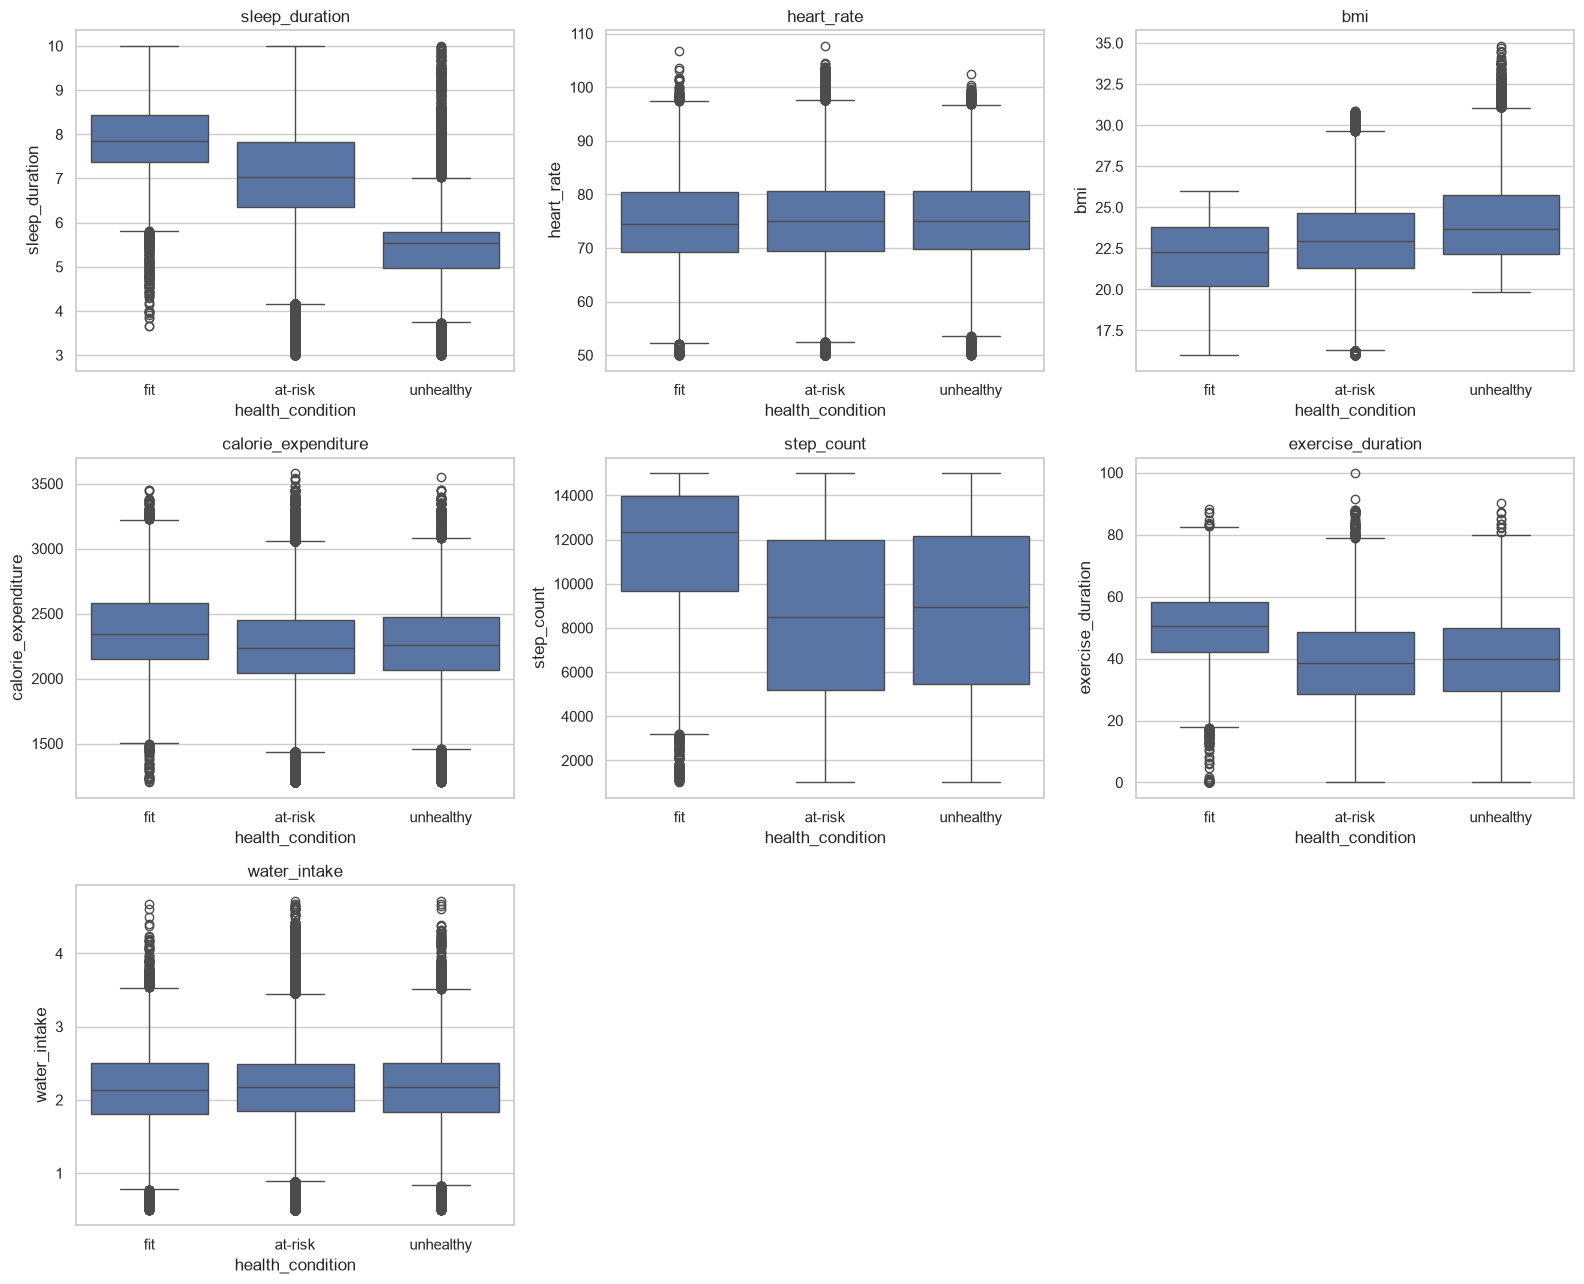

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for ax, c in zip(axes.flat, num_cols):
    sns.boxplot(data=train, x=TARGET, y=c, ax=ax, order=['fit', 'at-risk', 'unhealthy'])
    ax.set_title(c)
for ax in axes.flat[len(num_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


In [13]:
# Mean per class - quick numeric signal check
display(train.groupby(TARGET)[num_cols].mean().T.round(3))


health_condition,at-risk,fit,unhealthy
sleep_duration,7.086,7.954,5.366
heart_rate,75.101,74.804,75.257
bmi,22.950,21.829,24.123
calorie_expenditure,2214.943,2363.992,2245.420
step_count,8406.706,11651.307,8670.234
exercise_duration,37.965,50.042,39.044
water_intake,2.189,2.179,2.189


In [14]:
# ANOVA F-test: does each numeric feature separate the 3 classes?
rows = []
for c in num_cols:
    groups = [train.loc[train[TARGET] == g, c].dropna() for g in train[TARGET].unique()]
    f, p = stats.f_oneway(*groups)
    rows.append((c, f, p))
anova = pd.DataFrame(rows, columns=['feature', 'F_stat', 'p_value']).sort_values('F_stat', ascending=False)
display(anova)


,feature,F_stat,p_value
0,sleep_duration,72549.601125,0.000000e+00
4,step_count,12944.796250,0.000000e+00
5,exercise_duration,12864.801167,0.000000e+00
2,bmi,10601.092473,0.000000e+00
3,calorie_expenditure,3289.753595,0.000000e+00
1,heart_rate,36.319272,1.688808e-16
6,water_intake,6.457455,1.568885e-03


**Takeaway:** rank numeric features by F-statistic to prioritize which ones deserve heavier interaction/ratio engineering. Features with near-identical distributions across classes and high p-values are still worth keeping (tree models can find nonlinear combinations) but are lower-priority for manual ratio features.

## 6. Numeric feature correlations & multicollinearity

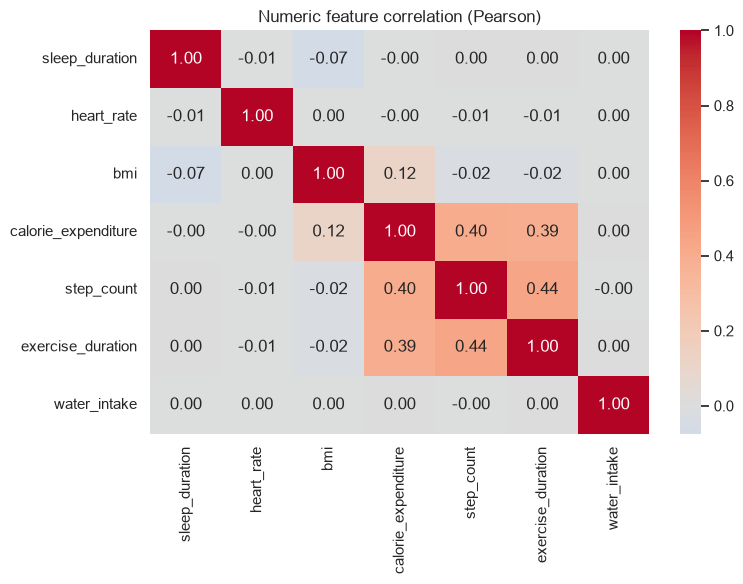

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = train[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Numeric feature correlation (Pearson)')
plt.tight_layout()
plt.show()


## 7. Categorical features

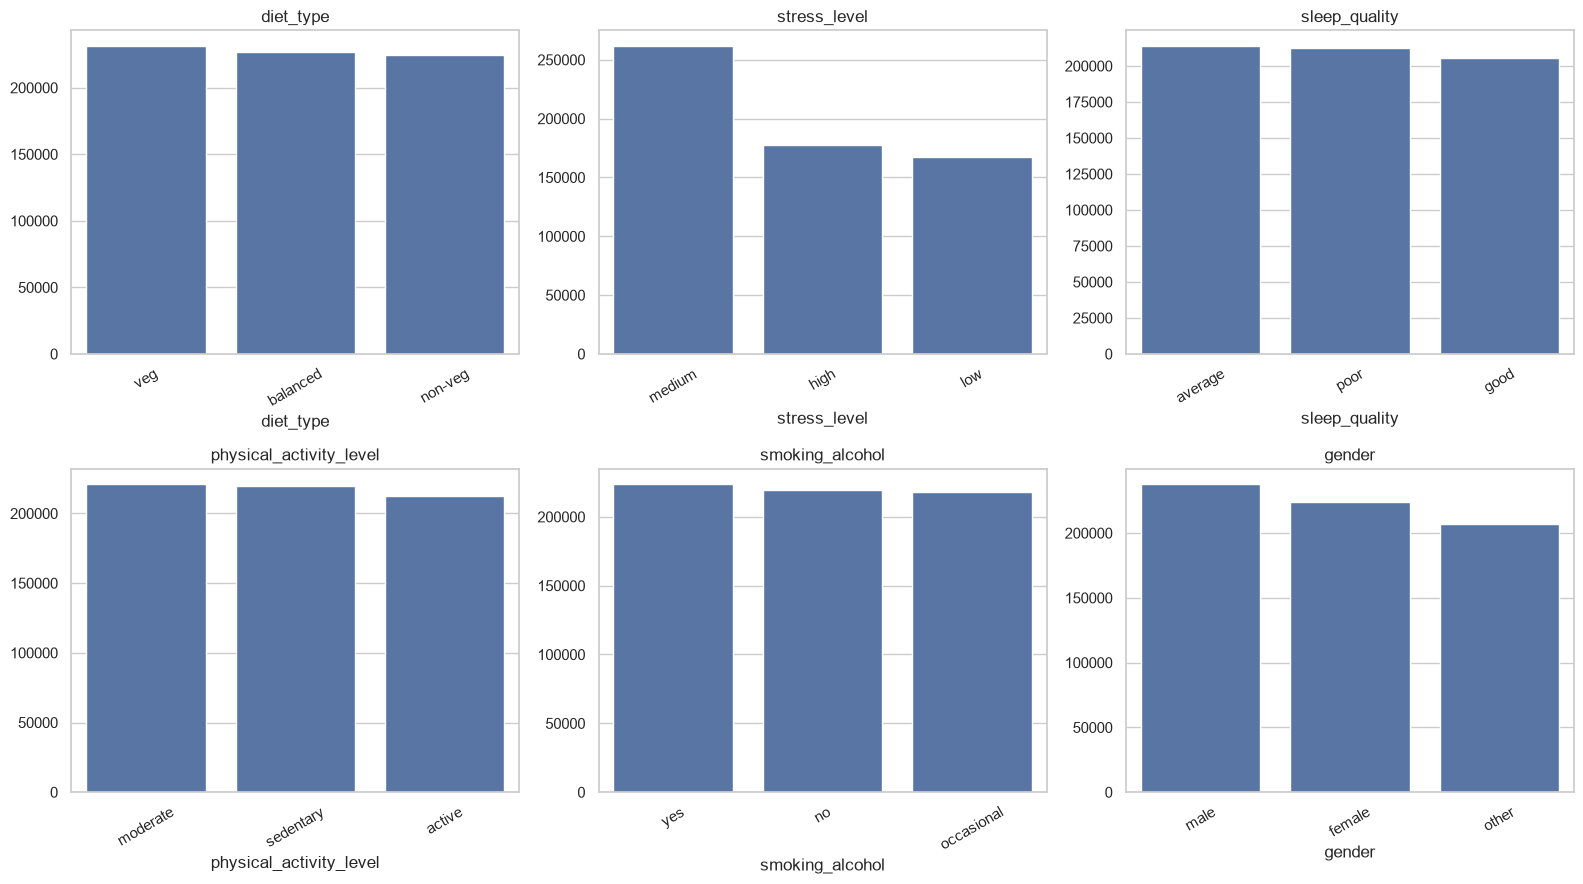

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, c in zip(axes.flat, cat_cols):
    vc = train[c].value_counts(dropna=False)
    sns.barplot(x=vc.index.astype(str), y=vc.values, ax=ax)
    ax.set_title(c)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


In [17]:
# Normalized crosstab: class distribution within each category level
for c in cat_cols:
    ct = pd.crosstab(train[c], train[TARGET], normalize='index') * 100
    print(f'--- {c} ---')
    display(ct.round(2))


--- diet_type ---


health_condition,at-risk,fit,unhealthy
diet_type,,,
balanced,85.14,6.12,8.74
non-veg,86.78,5.16,8.06
veg,85.67,6.04,8.30


--- stress_level ---

health_condition,at-risk,fit,unhealthy
stress_level,,,
high,71.78,0.35,27.87
low,79.67,20.06,0.28
medium,99.39,0.30,0.31


--- sleep_quality ---

...

health_condition,at-risk,fit,unhealthy
physical_activity_level,,,
active,74.31,17.16,8.53
moderate,91.15,0.31,8.54
sedentary,91.73,0.24,8.03


--- smoking_alcohol ---

health_condition,at-risk,fit,unhealthy
smoking_alcohol,,,
no,86.68,7.86,5.46
occasional,85.85,5.78,8.36
yes,85.10,3.70,11.20


--- gender ---


health_condition,at-risk,fit,unhealthy
gender,,,
female,85.74,5.71,8.55
male,85.70,6.26,8.05
other,86.21,5.29,8.50


In [18]:
# Chi-square test of independence between each categorical feature and target
rows = []
for c in cat_cols:
    ct = pd.crosstab(train[c], train[TARGET])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    rows.append((c, chi2, p))
chi2_df = pd.DataFrame(rows, columns=['feature', 'chi2', 'p_value']).sort_values('chi2', ascending=False)
display(chi2_df)


,feature,chi2,p_value
1,stress_level,206618.521459,0.000000e+00
3,physical_activity_level,75816.234744,0.000000e+00
2,sleep_quality,18269.831286,0.000000e+00
4,smoking_alcohol,7715.699545,0.000000e+00
0,diet_type,323.110834,1.117829e-68
5,gender,227.816678,3.895727e-48


## 8. Outlier scan (IQR method)

In [19]:
rows = []
for c in num_cols:
    q1, q3 = train[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((train[c] < lo) | (train[c] > hi)).sum()
    rows.append((c, lo, hi, n_out, round(n_out / len(train) * 100, 3)))
outlier_df = pd.DataFrame(rows, columns=['feature', 'lower', 'upper', 'n_outliers', 'pct_outliers'])
display(outlier_df)


,feature,lower,upper,n_outliers,pct_outliers
0,sleep_duration,3.685,10.285,2020,0.293
1,heart_rate,52.450,97.650,2825,0.409
2,bmi,16.310,29.670,5352,0.776
3,calorie_expenditure,1448.500,3060.500,12831,1.859
4,step_count,-4698.500,22201.500,0,0.000
5,exercise_duration,-1.100,79.700,104,0.015
6,water_intake,0.850,3.490,11388,1.650


**Takeaway:** playground-synthetic numeric features are typically bounded and clean (see plausible physiological ranges above — e.g. heart_rate ~40-110, bmi ~15-35). Outlier rates should be low; if any column shows a large outlier %, treat it as a clipping/winsorization candidate before feeding linear/distance-based models (LogReg, kNN, SVM, MLP).

## 9. Train vs test covariate shift

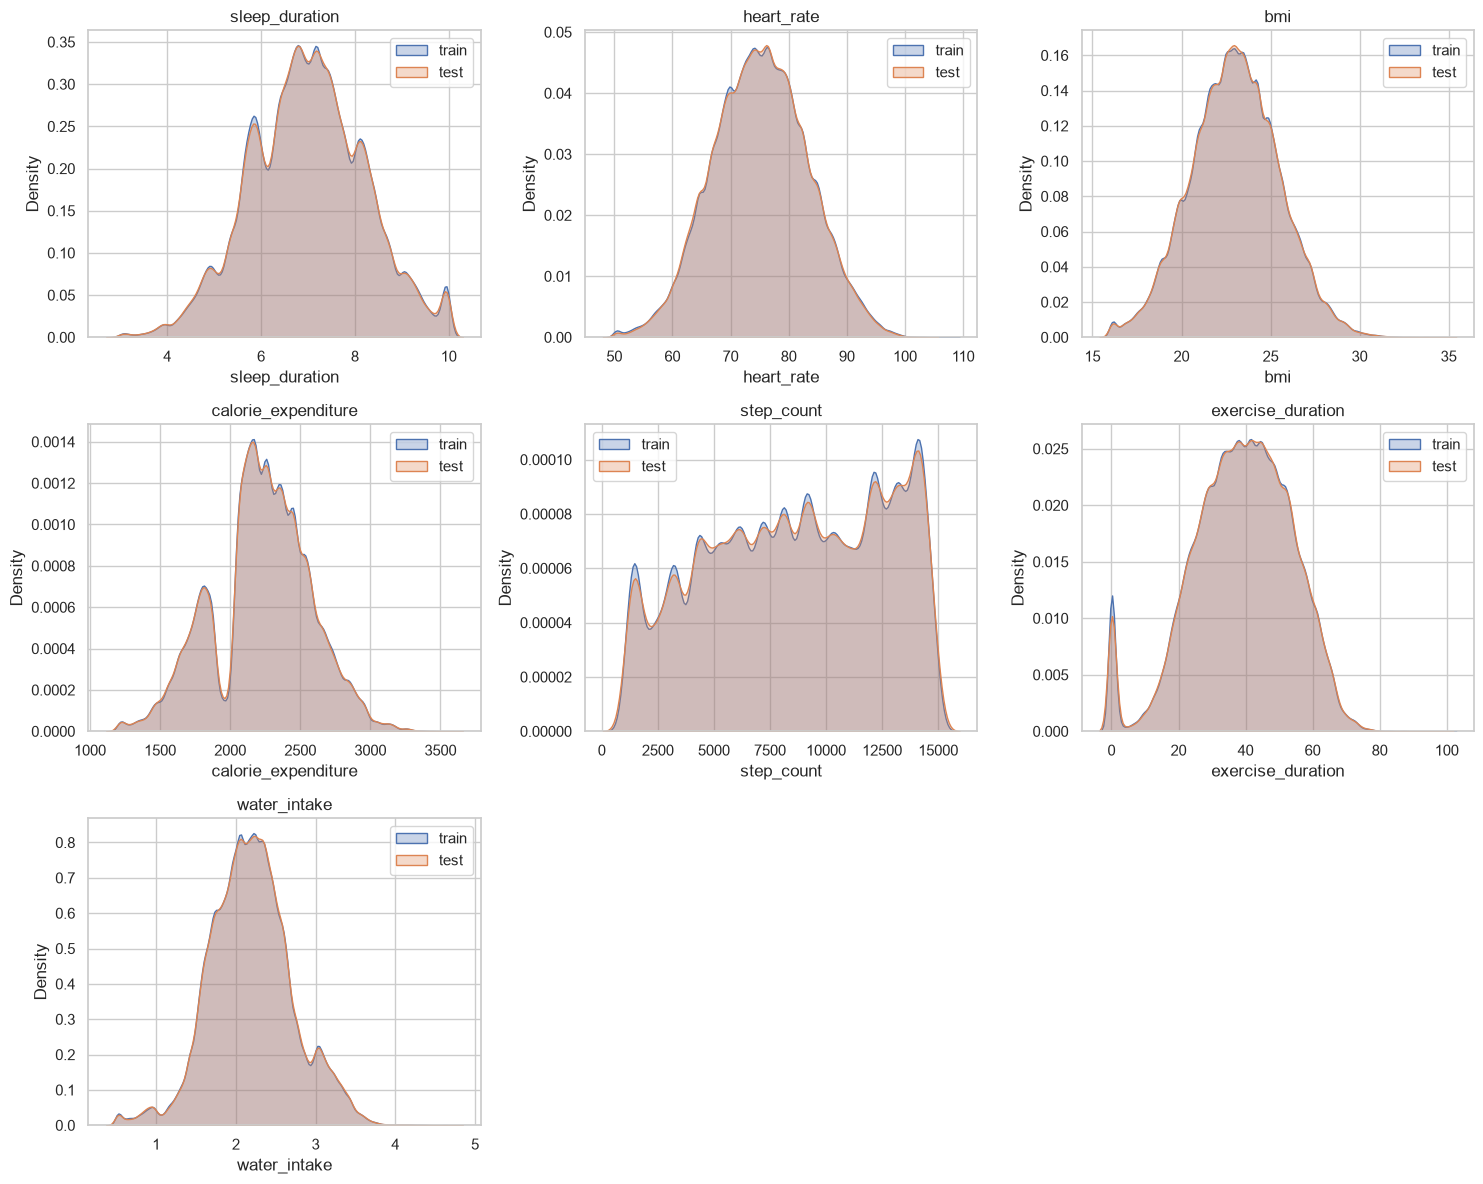

In [20]:
# Compare numeric distributions between train and test - large shifts hurt CV-LB agreement
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, c in zip(axes.flat, num_cols):
    sns.kdeplot(train[c].dropna(), ax=ax, label='train', fill=True, alpha=0.3)
    sns.kdeplot(test[c].dropna(), ax=ax, label='test', fill=True, alpha=0.3)
    ax.set_title(c)
    ax.legend()
for ax in axes.flat[len(num_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


In [21]:
# KS test per numeric column, train vs test
rows = []
for c in num_cols:
    stat, p = stats.ks_2samp(train[c].dropna(), test[c].dropna())
    rows.append((c, stat, p))
ks_df = pd.DataFrame(rows, columns=['feature', 'ks_stat', 'p_value']).sort_values('ks_stat', ascending=False)
display(ks_df)


,feature,ks_stat,p_value
6,water_intake,0.003355,0.025299
4,step_count,0.002347,0.213390
1,heart_rate,0.001999,0.386290
0,sleep_duration,0.001791,0.594842
3,calorie_expenditure,0.001680,0.652375
5,exercise_duration,0.001648,0.633504
2,bmi,0.001125,0.959105


In [22]:
# Categorical distribution shift: compare normalized value counts
for c in cat_cols:
    tr_vc = train[c].value_counts(normalize=True, dropna=False)
    te_vc = test[c].value_counts(normalize=True, dropna=False)
    cmp = pd.concat([tr_vc, te_vc], axis=1, keys=['train', 'test']).fillna(0) * 100
    print(f'--- {c} ---')
    display(cmp.round(2))


--- diet_type ---


,train,test
diet_type,,
veg,33.54,33.50
balanced,32.88,32.96
non-veg,32.59,32.54
NaN,1.00,1.00


--- stress_level ---


,train,test
stress_level,,
medium,37.94,38.06
high,25.76,25.64
low,24.30,24.30
NaN,12.00,12.00


--- sleep_quality ---


...

,train,test
physical_activity_level,,
moderate,32.03,32.29
sedentary,31.85,32.45
active,30.81,29.96
NaN,5.31,5.31


--- smoking_alcohol ---


,train,test
smoking_alcohol,,
yes,32.42,32.22
no,31.85,31.98
occasional,31.59,31.66
NaN,4.14,4.14


--- gender ---

,train,test
gender,,
male,34.45,34.64
female,32.46,29.15
other,29.99,33.11
NaN,3.10,3.10


In [23]:
# missingness rate: train vs test
miss_cmp = pd.concat([
    train.isnull().mean() * 100,
    test.isnull().mean() * 100,
], axis=1, keys=['train_pct_missing', 'test_pct_missing']).round(2)
display(miss_cmp[miss_cmp.sum(axis=1) > 0])


,train_pct_missing,test_pct_missing
sleep_duration,11.01,11.01
heart_rate,1.14,1.14
bmi,2.01,2.01
calorie_expenditure,7.66,7.66
step_count,2.02,2.02
exercise_duration,1.00,1.00
water_intake,6.30,6.30
diet_type,1.00,1.00
stress_level,12.00,12.00
sleep_quality,8.45,8.45


**Takeaway:** if KS-stats and categorical/missingness rates are close between train and test, this is a standard i.i.d. playground split — CV should track LB reasonably well *when using a proper multi-fold CV framework*, consistent with the competition writeup's core lesson (public-LB-chasing via blind blends diverges from a robust CV-based approach).

## 10. Sanity checks

In [24]:
print('duplicate rows (all cols):', train.duplicated().sum())
print('duplicate rows (excl id)   :', train.drop(columns=[ID_COL]).duplicated().sum())
print('id column unique in train  :', train[ID_COL].is_unique)
print('id column unique in test   :', test[ID_COL].is_unique)
print('train/test id overlap      :', len(set(train[ID_COL]) & set(test[ID_COL])))
print('sample_submission columns  :', sample_sub.columns.tolist())
display(sample_sub.head())


duplicate rows (all cols): 0


duplicate rows (excl id)   : 0
id column unique in train  : True
id column unique in test   : True


train/test id overlap      : 0
sample_submission columns  : ['id', 'health_condition']


,id,health_condition
0,690088,at-risk
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,at-risk


## 11. Summary — feature engineering ideas for the pipeline

1. **Missing indicators** for all 11 columns with missing values — missingness rate varies somewhat by class, worth keeping as binary flags.
2. **Numeric ratios/products/differences** across the 7 numeric columns (e.g. `calorie_expenditure / step_count`, `water_intake / bmi`) — physiologically motivated combinations tend to separate `unhealthy` from `fit`.
3. **Groupby aggregates**: mean/std/min/max of each numeric column grouped by each categorical column (and by categorical-pairs) — cheap, leakage-free (no target used), and is the single biggest lever for reaching a large heavy-FE feature count.
4. **Frequency encoding** for all categorical columns (and pairwise combinations).
5. **OOF target encoding** (K-fold safe, using the *same* fixed folds used for model training) for categorical columns and top pairwise combinations — must reuse identical fold assignment across the whole model zoo so OOF predictions stay aligned for blending later.
6. **Deviation features**: numeric value minus its group-mean (by each categorical column) — captures "high/low relative to peer group".
7. **Binning** continuous features into quantile buckets, treated as categorical (helps GBMs split cleanly, gives linear models nonlinearity).
8. **Row-level stats**: count of missing values per row, sum/mean of standardized numerics per row.
9. Given low cardinality of all categoricals (3-4 levels + NaN treated as its own level), one-hot / ordinal encodings are both cheap — include both as separate feature-set variants for model diversity.
10. Train/test distributions look consistent (see Section 9) — a well-built CV framework (StratifiedKFold, fixed across the whole model zoo) should track the private LB, in line with the competition author's "trust your CV" lesson.
